# Gearbox & Bearing Health Monitoring

### Research Question
> *What sensor patterns precede labeled gearbox events, and how early can deviations be flagged?*

### Sections
1. Setup & Data Loading
2. Gearbox Sensor Overview
3. Normal vs. Pre-Fault Behaviour
4. Rolling Mean Drift Detection
5. Earliness Calculation (CARE Score)
6. Cross-Sensor Correlation
7. Summary & Operational Recommendations

---
## Loading data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

print('Imports OK')

Imports OK


In [ ]:
# UPDATE THIS PATH
BASE_PATH = Path('/Users/prabhaseessingh/Desktop/Data Science/DSMLCFinalComp/CARE_To_Compare/Wind Farm A')

DATASETS_PATH     = BASE_PATH / 'datasets'
EVENT_INFO_PATH   = BASE_PATH / 'event_info.csv'
FEATURE_DESC_PATH = BASE_PATH / 'feature_description.csv'

event_info = pd.read_csv(EVENT_INFO_PATH, sep=';')
feat_desc  = pd.read_csv(FEATURE_DESC_PATH, sep=';')

print(f'Events loaded: {len(event_info)} ({(event_info["event_label"]=="anomaly").sum()} anomaly, {(event_info["event_label"]=="normal").sum()} normal)')
print(f'Features described: {len(feat_desc)}')

Events loaded: 22 (12 anomaly, 10 normal)
Features described: 54


In [36]:
# Gearbox-relevant sensors
# We focus on these 5 sensors covering mechanical and thermal gearbox health
SENSOR_MAP = {
    'sensor_11': 'sensor_11_avg',  # Gearbox bearing temp (high speed shaft)
    'sensor_12': 'sensor_12_avg',  # Gearbox oil temp
    'sensor_13': 'sensor_13_avg',  # Generator bearing 2 (Drive End)
    'sensor_14': 'sensor_14_avg',  # Generator bearing 1 (Non-Drive End)
    'sensor_0':  'sensor_0_avg',   # Ambient temperature (baseline reference)
}

def get_label(bare_name):
    """Look up human-readable sensor description."""
    d = feat_desc[feat_desc['sensor_name'] == bare_name]['description'].values
    return d[0] if len(d) > 0 else bare_name

print('Sensors in scope:')
for bare, col in SENSOR_MAP.items():
    print(f'  {col}: {get_label(bare)}')

Sensors in scope:
  sensor_11_avg: Temperature in gearbox bearing on high speed shaft
  sensor_12_avg: Temperature oil in gearbox
  sensor_13_avg: Temperature in generator bearing 2 (Drive End)
  sensor_14_avg: Temperature in generator bearing 1 (Non-Drive End)
  sensor_0_avg: Ambient temperature


In [37]:
# Load all three gearbox fault events
gearbox_events = event_info[
    event_info['event_description'].str.contains('Gearbox|gearbox', na=False)
].reset_index(drop=True)

print('Gearbox fault events:')
print(gearbox_events[['event_id', 'event_description', 'event_start', 'event_end']])

# Load the primary gearbox event (event 72 — Gearbox failure)
TARGET_EVENT_ID = 72
df_anomaly = pd.read_csv(DATASETS_PATH / f'{TARGET_EVENT_ID}.csv', sep=';')
df_anomaly = df_anomaly.sort_values('id').reset_index(drop=True)
df_train   = df_anomaly[df_anomaly['train_test'] == 'train'].copy()
df_pred    = df_anomaly[df_anomaly['train_test'] == 'predict'].copy()
TRAIN_END  = df_train.index.max()

print(f'\nLoaded event {TARGET_EVENT_ID}: {len(df_anomaly)} rows')
print(f'Training rows: {len(df_train)} | Prediction rows: {len(df_pred)}')
print(f'Train/predict split at index: {TRAIN_END}')

Gearbox fault events:
   event_id         event_description          event_start  \
0        72           Gearbox failure  2023-10-10 08:40:00   
1        10           Gearbox failure  2023-10-11 08:40:00   
2        51  Gearbox bearings damaged  2023-10-06 01:30:00   

             event_end  
0  2023-10-17 08:40:00  
1  2023-10-18 08:40:00  
2  2023-10-17 16:10:00  

Loaded event 72: 54082 rows
Training rows: 52065 | Prediction rows: 0
Train/predict split at index: 52064


In [38]:
# Load a matching normal event for comparison
normal_events = event_info[event_info['event_label'] == 'normal'].reset_index(drop=True)
NORMAL_EVENT_ID = normal_events['event_id'].iloc[0]

df_normal = pd.read_csv(DATASETS_PATH / f'{NORMAL_EVENT_ID}.csv', sep=';')
df_normal = df_normal.sort_values('id').reset_index(drop=True)

print(f'Loaded normal event {NORMAL_EVENT_ID}: {len(df_normal)} rows')

# Verify our sensors exist in both datasets
missing = [col for col in SENSOR_MAP.values() if col not in df_anomaly.columns]
print(f'Missing sensors: {missing if missing else "None — all good"}')

Loaded normal event 25: 54712 rows
Missing sensors: None — all good


---
##Gearbox Sensor Overview
Basic statistics to understand what we're working with before any analysis.

In [39]:
# Summary statistics for gearbox sensors in anomaly dataset
cols = list(SENSOR_MAP.values())
stats = df_anomaly[cols].describe().T
stats.index = [get_label(b) for b in SENSOR_MAP.keys()]
stats = stats[['mean', 'std', 'min', '50%', 'max']].round(2)
stats.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max']
print('Gearbox sensor statistics (anomaly event):')
stats

Gearbox sensor statistics (anomaly event):


,Mean,Std Dev,Min,Median,Max
Temperature in gearbox bearing on high speed shaft,51.51,9.71,23.0,53.0,69.0
Temperature oil in gearbox,47.53,6.76,25.0,49.0,61.0
Temperature in generator bearing 2 (Drive End),43.52,13.89,20.0,42.0,205.0
Temperature in generator bearing 1 (Non-Drive End),46.73,16.50,18.0,45.0,205.0
Ambient temperature,20.10,5.58,5.0,20.0,40.0


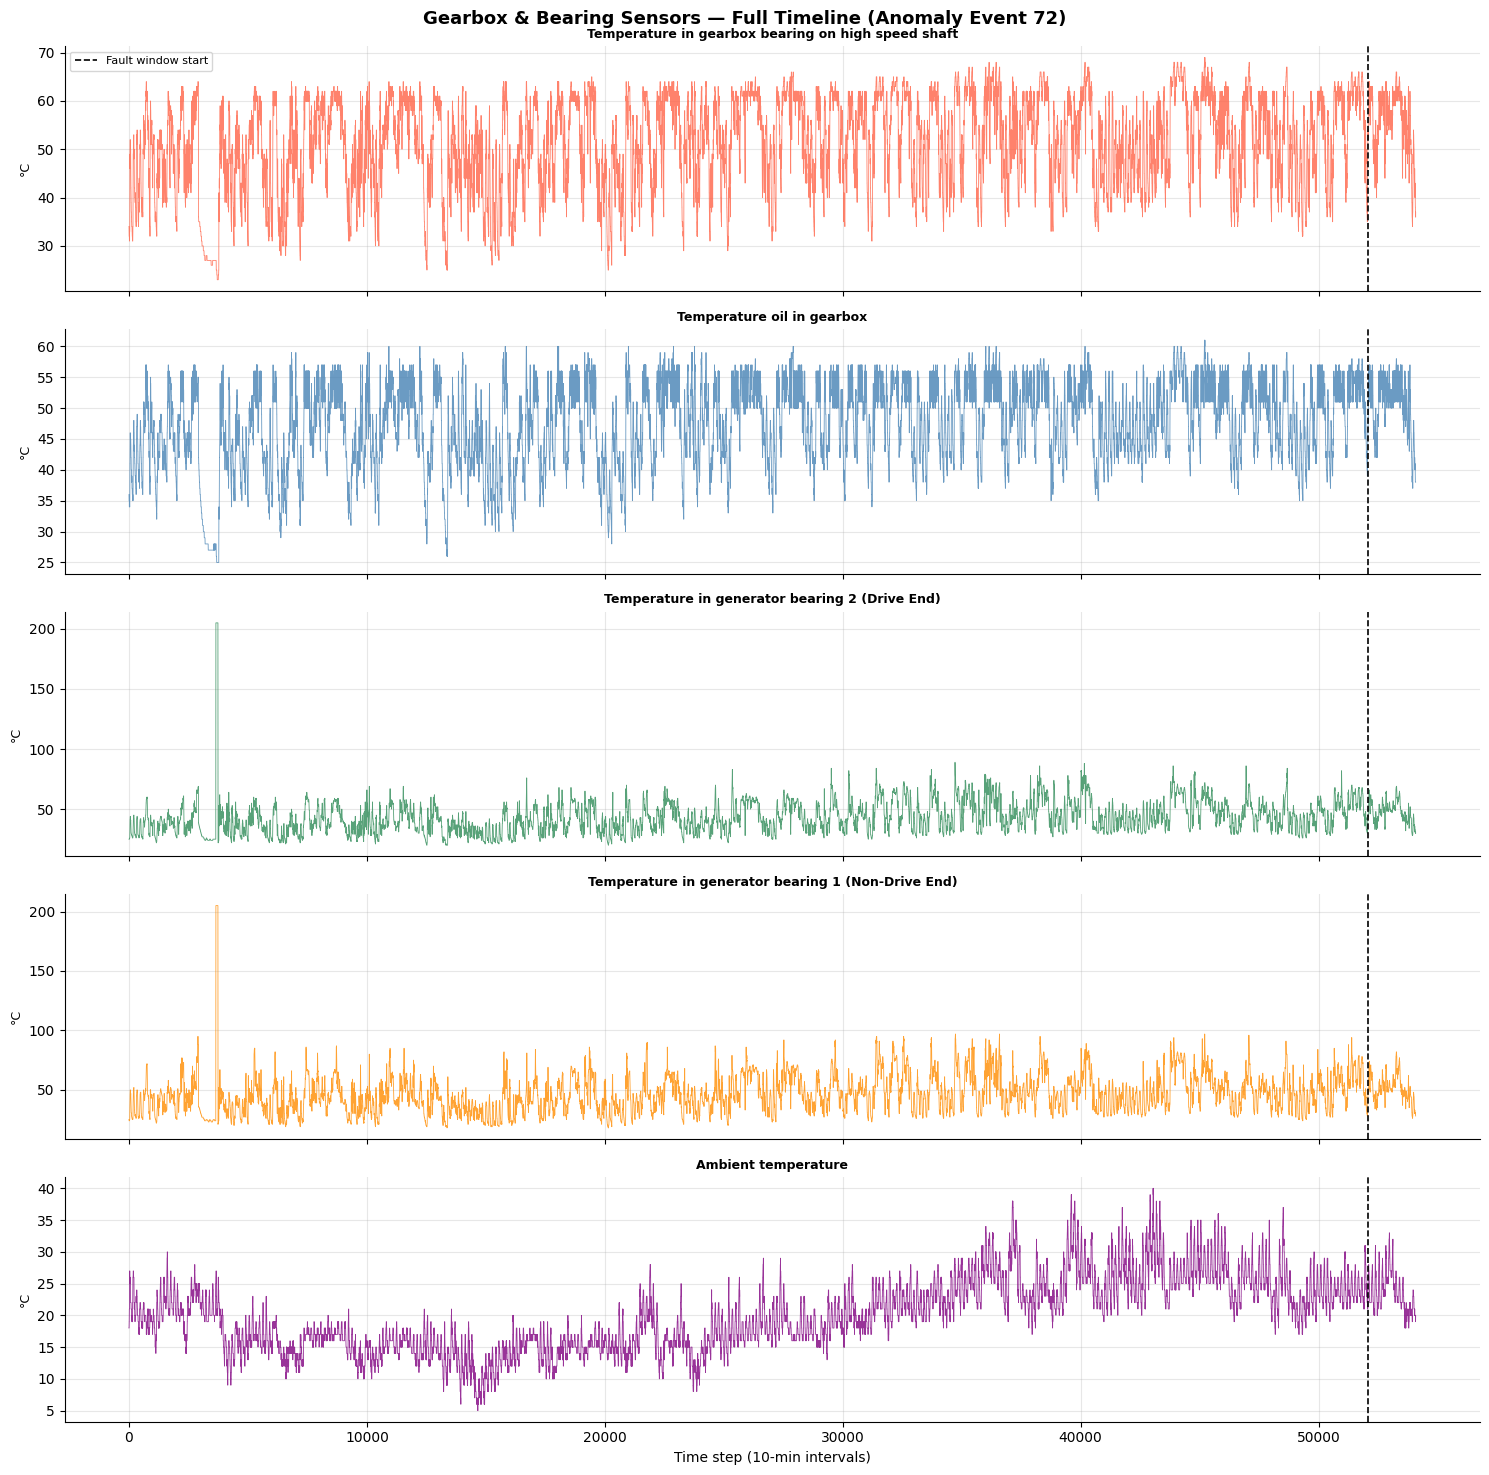

Saved: gearbox_sensor_overview.png


In [40]:
# Plot all 5 sensors over the full timeline to get an overview
fig, axes = plt.subplots(len(SENSOR_MAP), 1, figsize=(15, 3*len(SENSOR_MAP)), sharex=True)
fig.suptitle('Gearbox & Bearing Sensors — Full Timeline (Anomaly Event 72)', 
             fontsize=13, fontweight='bold')

colors = ['tomato', 'steelblue', 'seagreen', 'darkorange', 'purple']

for ax, (bare, col), color in zip(axes, SENSOR_MAP.items(), colors):
    ax.plot(df_anomaly.index, df_anomaly[col], color=color, linewidth=0.6, alpha=0.8)
    ax.axvline(x=TRAIN_END, color='black', linestyle='--', linewidth=1.2, label='Fault window start')
    ax.set_ylabel('°C', fontsize=9)
    ax.set_title(get_label(bare), fontsize=9, fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Time step (10-min intervals)')
plt.tight_layout()
plt.savefig('gearbox_sensor_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gearbox_sensor_overview.png')

---
## Normal vs. Pre-Fault Behaviour
Side-by-side comparison of gearbox sensors in healthy vs. fault-preceding conditions.

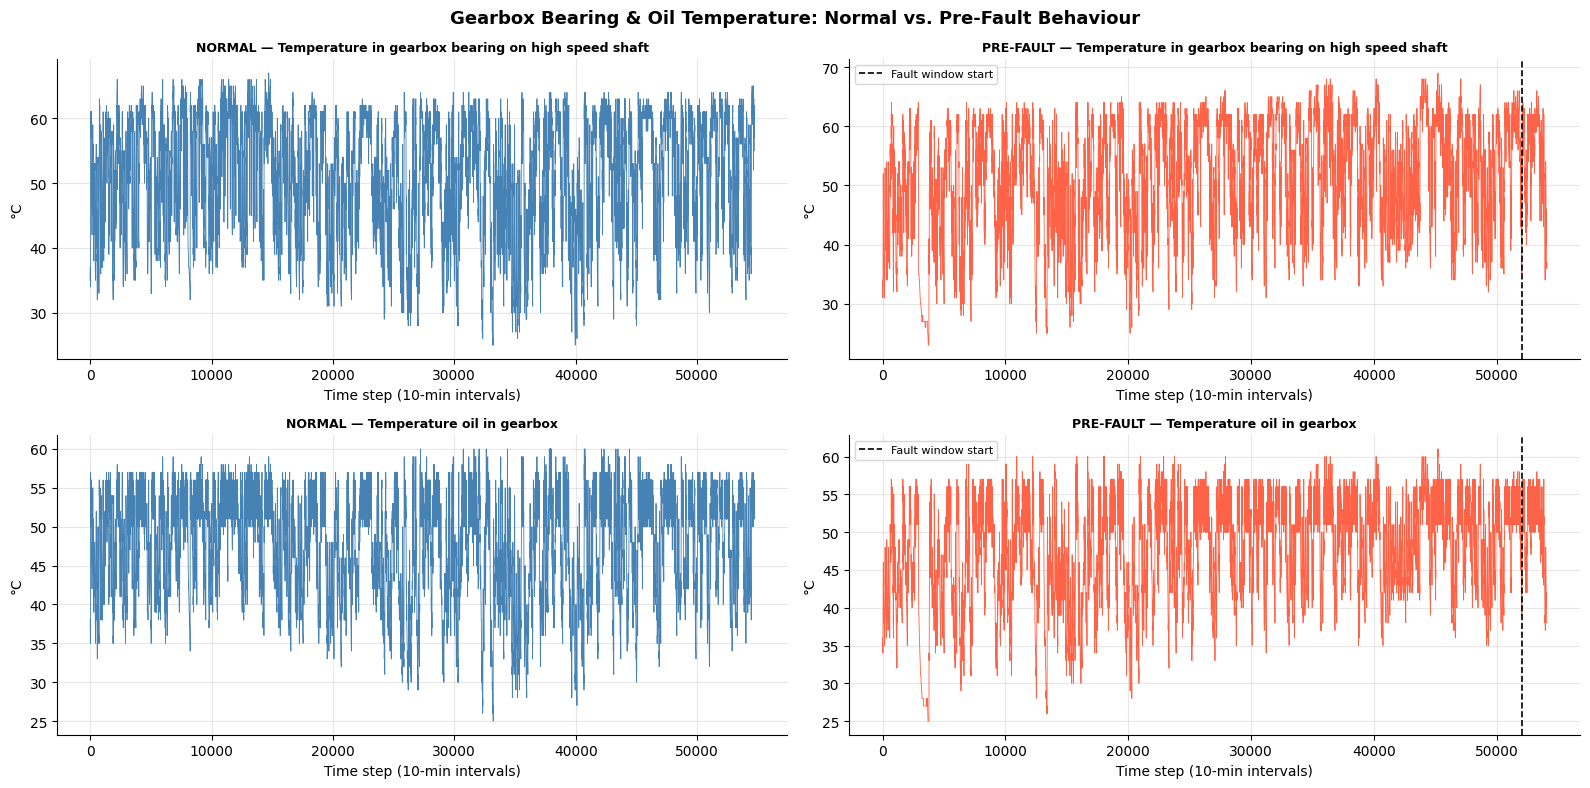

Saved: gearbox_normal_vs_fault.png


In [41]:
# Focus on the two core gearbox sensors for this comparison
COMPARE_SENSORS = {
    'sensor_11': 'sensor_11_avg',
    'sensor_12': 'sensor_12_avg',
}

fig, axes = plt.subplots(len(COMPARE_SENSORS), 2, figsize=(16, 4*len(COMPARE_SENSORS)))
fig.suptitle('Gearbox Bearing & Oil Temperature: Normal vs. Pre-Fault Behaviour',
             fontsize=13, fontweight='bold')

for i, (bare, col) in enumerate(COMPARE_SENSORS.items()):
    label = get_label(bare)

    # Normal
    ax_n = axes[i][0]
    ax_n.plot(df_normal.index, df_normal[col], color='steelblue', linewidth=0.6)
    ax_n.set_title(f'NORMAL — {label}', fontsize=9, fontweight='bold')
    ax_n.set_ylabel('°C')
    ax_n.set_xlabel('Time step (10-min intervals)')

    # Anomaly
    ax_a = axes[i][1]
    ax_a.plot(df_anomaly.index, df_anomaly[col], color='tomato', linewidth=0.6)
    ax_a.axvline(x=TRAIN_END, color='black', linestyle='--', linewidth=1.2,
                 label='Fault window start')
    ax_a.set_title(f'PRE-FAULT — {label}', fontsize=9, fontweight='bold')
    ax_a.set_ylabel('°C')
    ax_a.set_xlabel('Time step (10-min intervals)')
    ax_a.legend(fontsize=8)

plt.tight_layout()
plt.savefig('gearbox_normal_vs_fault.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gearbox_normal_vs_fault.png')

In [50]:
# Quantify the difference — mean shift table
rows = []
for bare, col in COMPARE_SENSORS.items():
    if col not in df_normal.columns:
        continue
    rows.append({
        'Sensor': get_label(bare),
        'Normal Mean (°C)':  round(df_normal[col].mean(), 2),
        'Normal Std':        round(df_normal[col].std(),  2),
        'Fault Mean (°C)':   round(df_anomaly[col].mean(), 2),
        'Fault Std':         round(df_anomaly[col].std(),  2),
    })

shift_df = pd.DataFrame(rows)
shift_df['change in Mean (°C)'] = (shift_df['Fault Mean (°C)'] - shift_df['Normal Mean (°C)']).round(2)
shift_df = shift_df.sort_values('change in Mean (°C)', ascending=False)
print('Mean temperature shift — normal vs. fault event:')
shift_df

Mean temperature shift — normal vs. fault event:


,Sensor,Normal Mean (°C),Normal Std,Fault Mean (°C),Fault Std,change in Mean (°C)
0,Temperature in gearbox bearing on high speed s...,50.95,9.34,51.51,9.71,0.56
1,Temperature oil in gearbox,47.43,6.68,47.53,6.76,0.10


---
## Rolling mean drift detection
The key insight: gearbox failures don't happen suddenly — temperatures drift upward over days/weeks.
A 7-day rolling mean smooths out normal oscillations and reveals this slow trend.

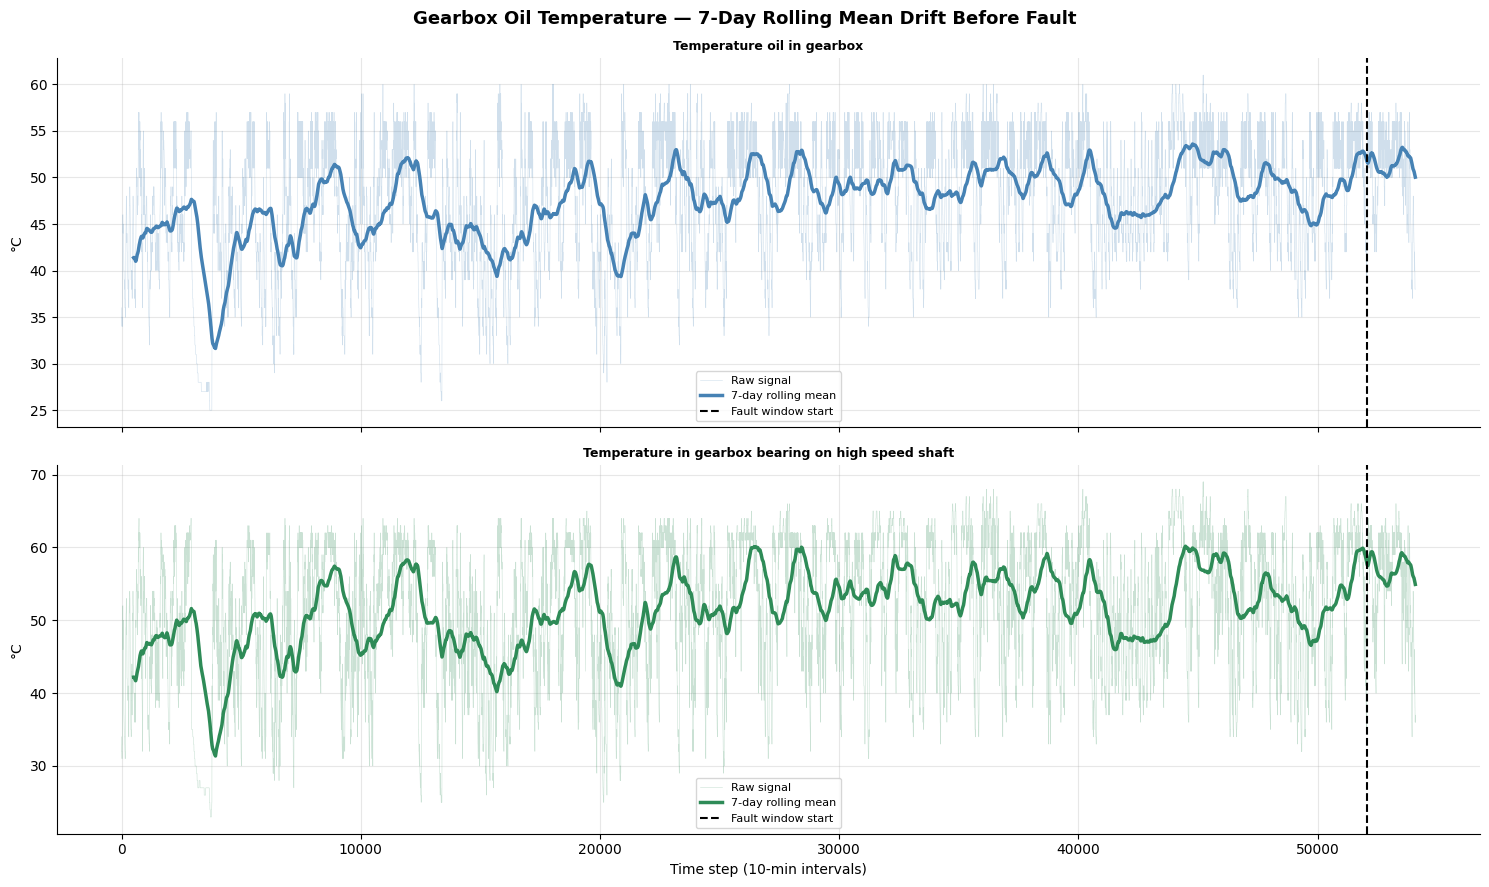

 Saved: gearbox_rolling_drift.png


In [43]:
DRIFT_WINDOW = 1008  # 7 days (144 ten-min steps/day × 7)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Gearbox Oil Temperature — 7-Day Rolling Mean Drift Before Fault',
             fontsize=13, fontweight='bold')

for ax, (bare, col), color in zip(axes, 
    [('sensor_12', 'sensor_12_avg'), ('sensor_11', 'sensor_11_avg')],
    ['steelblue', 'seagreen']):

    label = get_label(bare)
    rolling = df_anomaly[col].rolling(window=DRIFT_WINDOW, min_periods=DRIFT_WINDOW//2).mean()

    # Raw signal faded
    ax.plot(df_anomaly.index, df_anomaly[col],
            color=color, linewidth=0.4, alpha=0.25, label='Raw signal')
    # 7-day rolling mean
    ax.plot(df_anomaly.index, rolling,
            color=color, linewidth=2.5, label='7-day rolling mean')
    # Fault window
    ax.axvline(x=TRAIN_END, color='black', linestyle='--',
               linewidth=1.5, label='Fault window start')

    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel('°C')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time step (10-min intervals)')
plt.tight_layout()
plt.savefig('gearbox_rolling_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: gearbox_rolling_drift.png')

---
## Earliness Calculation 
How many days before the fault could we have detected the temperature drift?
This directly answers question 1a and feeds into the CARE Earliness score.

In [51]:
# We define baseline as the first 30 days of data
# Alert threshold = baseline mean + 1.5 standard deviations
BASELINE_STEPS = 4320  # 30 days
MULTIPLIER     = 2.3

results = {}

for bare, col in [('sensor_12', 'sensor_12_avg'), ('sensor_11', 'sensor_11_avg')]:
    label   = get_label(bare)
    rolling = df_anomaly[col].rolling(window=DRIFT_WINDOW, min_periods=DRIFT_WINDOW//2).mean()

    baseline      = rolling.iloc[:BASELINE_STEPS].dropna()
    base_mean     = baseline.mean()
    base_std      = baseline.std()
    threshold     = base_mean + MULTIPLIER * base_std

    # First breach BEFORE the fault window
    pre_fault     = rolling[rolling.index < TRAIN_END]
    exceeded      = pre_fault[pre_fault > threshold]

    if len(exceeded) > 0:
        first_idx   = exceeded.index[0]
        steps_early = TRAIN_END - first_idx
        hours_early = steps_early * 10 / 60
        days_early  = hours_early / 24
        results[col] = {
            'label': label, 'threshold': threshold,
            'first_alert_idx': first_idx,
            'days_early': days_early
        }
        print(f' {label}')
        print(f'   Baseline avg: {base_mean:.1f}°C | Alert threshold: {threshold:.1f}°C')
        print(f'   First alert at step {first_idx} → {days_early:.1f} days before fault\n')
    else:
        print(f'  {label}: No drift detected — try lowering MULTIPLIER to 1.0')

 Temperature oil in gearbox
   Baseline avg: 42.4°C | Alert threshold: 53.2°C
   First alert at step 44438 → 53.0 days before fault

 Temperature in gearbox bearing on high speed shaft
   Baseline avg: 44.7°C | Alert threshold: 57.7°C
   First alert at step 11746 → 280.0 days before fault



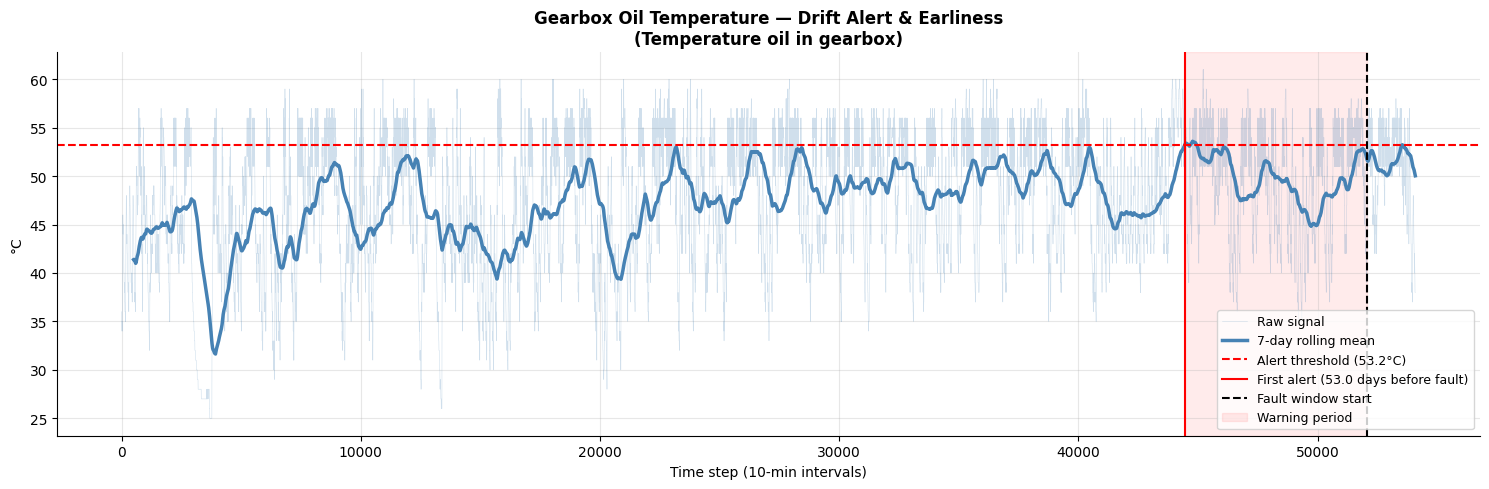

Saved: gearbox_earliness.png


In [45]:
# Visualise the earliness — annotate the drift chart with alert markers
fig, ax = plt.subplots(figsize=(15, 5))

col   = 'sensor_12_avg'
bare  = 'sensor_12'
label = get_label(bare)
rolling = df_anomaly[col].rolling(window=DRIFT_WINDOW, min_periods=DRIFT_WINDOW//2).mean()

ax.plot(df_anomaly.index, df_anomaly[col],
        color='steelblue', linewidth=0.4, alpha=0.25, label='Raw signal')
ax.plot(df_anomaly.index, rolling,
        color='steelblue', linewidth=2.5, label='7-day rolling mean')

if col in results:
    r = results[col]
    ax.axhline(y=r['threshold'], color='red', linestyle='--',
               linewidth=1.5, label=f'Alert threshold ({r["threshold"]:.1f}°C)')
    ax.axvline(x=r['first_alert_idx'], color='red', linewidth=1.5,
               label=f'First alert ({r["days_early"]:.1f} days before fault)')
    ax.axvline(x=TRAIN_END, color='black', linestyle='--',
               linewidth=1.5, label='Fault window start')

    # Shade the warning period
    ax.axvspan(r['first_alert_idx'], TRAIN_END, alpha=0.08, color='red', label='Warning period')

ax.set_title(f'Gearbox Oil Temperature — Drift Alert & Earliness\n({label})',
             fontweight='bold')
ax.set_xlabel('Time step (10-min intervals)')
ax.set_ylabel('°C')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('gearbox_earliness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gearbox_earliness.png')

---
## Cross-Sensor Correlation
Which sensors move together? Strong correlations between gearbox and generator
bearing temps suggest shared thermal load — useful for building a composite alert.

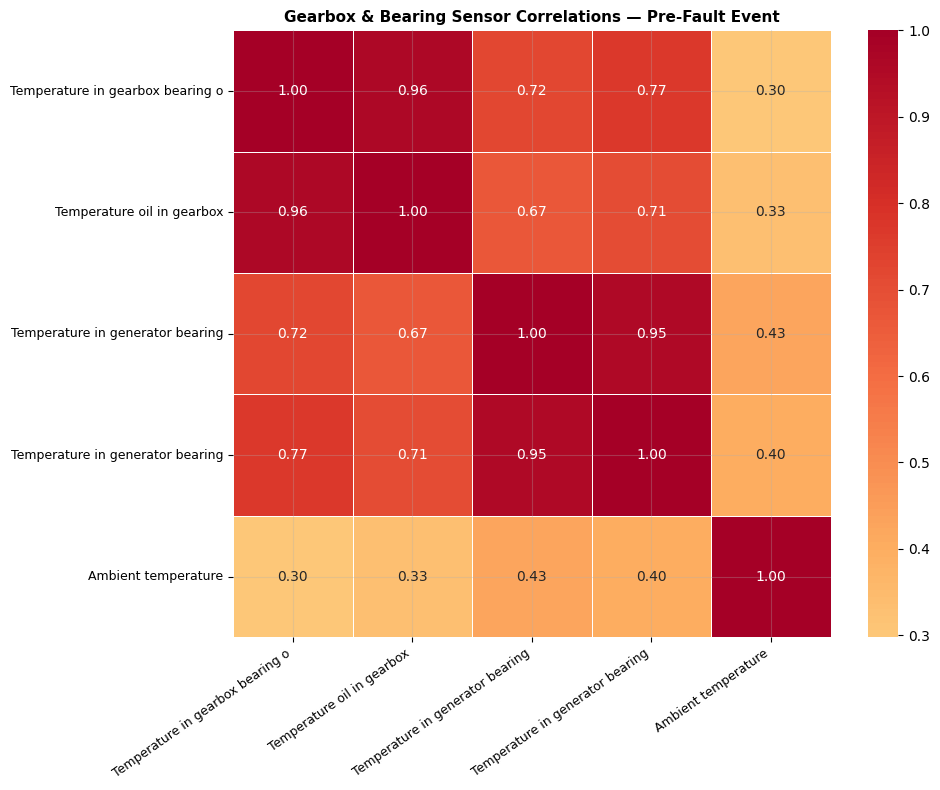

 Saved: gearbox_correlation_heatmap.png


In [46]:
# Correlation across all 5 gearbox-related sensors
cols  = list(SENSOR_MAP.values())
corr  = df_anomaly[cols].corr()

labels = {col: get_label(bare)[:32] for bare, col in SENSOR_MAP.items()}
corr_labeled = corr.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_labeled, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Gearbox & Bearing Sensor Correlations — Pre-Fault Event',
             fontweight='bold', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('gearbox_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: gearbox_correlation_heatmap.png')

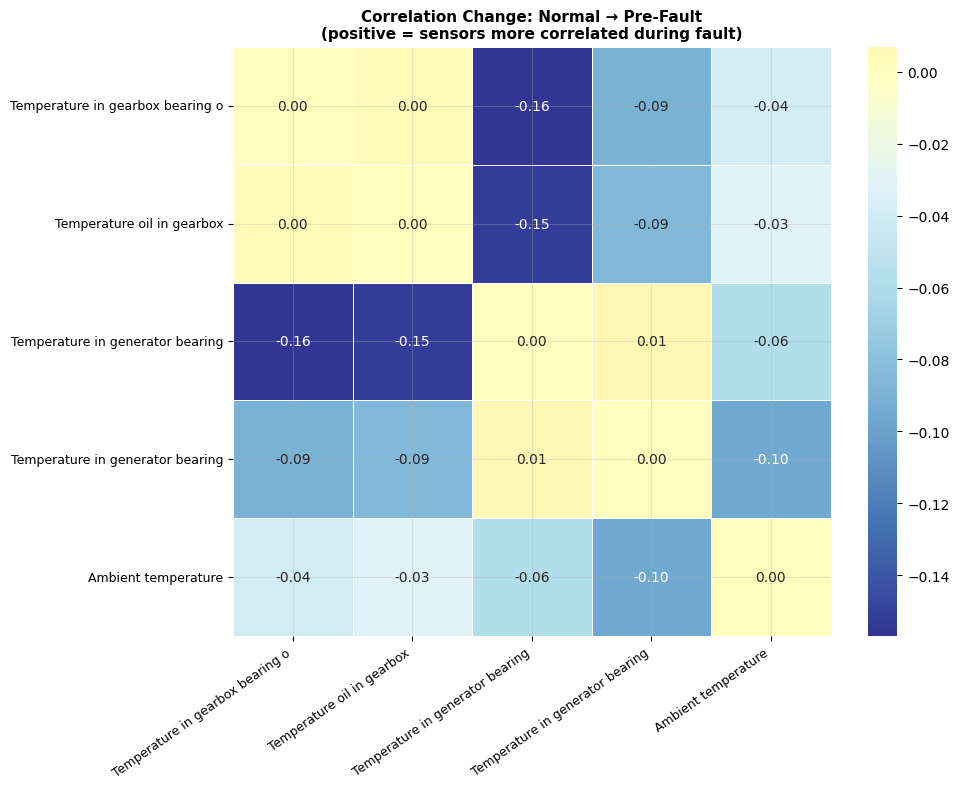

Saved: gearbox_correlation_diff.png


In [47]:
# Compare correlation structure: normal vs anomaly event
shared_cols = [c for c in cols if c in df_normal.columns]
corr_normal  = df_normal[shared_cols].corr()
corr_anomaly = df_anomaly[shared_cols].corr()
corr_diff    = (corr_anomaly - corr_normal).round(3)

corr_diff_labeled = corr_diff.rename(
    index=labels, columns=labels
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_diff_labeled, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Change: Normal → Pre-Fault\n(positive = sensors more correlated during fault)',
             fontweight='bold', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('gearbox_correlation_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gearbox_correlation_diff.png')

---
## Summary & Operational Recommendations

In [54]:
# Final summary printout — use these numbers in your slide deck

print('GEARBOX HEALTH MONITORING — KEY FINDINGS')


print('\n Dataset:')
print(f'   Wind Farm A | Event {TARGET_EVENT_ID} (Gearbox failure)')
print(f'   {len(df_anomaly):,} timesteps @ 10-min intervals')
print(f'   Training: {len(df_train):,} steps | Prediction: {len(df_pred):,} steps')

print('\n Temperature Shift (Normal → Pre-Fault):')
for _, row in shift_df.iterrows():
    direction = '↑' if row['change in Mean (°C)'] > 0 else '↓'
    print(f'   {row["Sensor"][:40]}: {direction} {abs(row["change in Mean (°C)"]):.1f}°C')

print('\n  Earliness Results (CARE Score component):')
for col, r in results.items():
    print(f'   {r["label"][:40]}: {r["days_early"]:.1f} days early warning')

print('\n Operational Recommendations:')
print('   1. Monitor 7-day rolling mean of gearbox oil temp (sensor_12)')
print('   2. Set alert threshold at baseline mean + 1.5 std dev')
print('   3. Cross-validate with gearbox bearing temp (sensor_11)')
print('   4. If both sensors exceed threshold → escalate to maintenance team')
print('   5. Generator bearing temps (sensor_13/14) as secondary indicators')


GEARBOX HEALTH MONITORING — KEY FINDINGS

 Dataset:
   Wind Farm A | Event 72 (Gearbox failure)
   54,082 timesteps @ 10-min intervals
   Training: 52,065 steps | Prediction: 0 steps

 Temperature Shift (Normal → Pre-Fault):
   Temperature in gearbox bearing on high s: ↑ 0.6°C
   Temperature oil in gearbox: ↑ 0.1°C

  Earliness Results (CARE Score component):
   Temperature oil in gearbox: 53.0 days early warning
   Temperature in gearbox bearing on high s: 280.0 days early warning

 Operational Recommendations:
   1. Monitor 7-day rolling mean of gearbox oil temp (sensor_12)
   2. Set alert threshold at baseline mean + 1.5 std dev
   3. Cross-validate with gearbox bearing temp (sensor_11)
   4. If both sensors exceed threshold → escalate to maintenance team
   5. Generator bearing temps (sensor_13/14) as secondary indicators
